In [1]:
import sys, os
import re
import gc
import glob
import pandas as pd
import copy
import joblib
import ast
import itertools
import numpy as np
import pickle
from pathlib import Path

In [2]:
import graphviz
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from tqdm.notebook import tqdm

tqdm.pandas()

In [4]:
import warnings
warnings.filterwarnings("ignore")

### Loading package

In [5]:
import sys
from pathlib import Path

here_path = Path().resolve()
repo_path = here_path.parents[1]
sys.path.append(str(repo_path))

In [6]:
from py.utils import verifyDir, verifyFile

In [7]:
from py.config import Config

cfg = Config()

np.random.seed(cfg.RANDOM_STATE)
cfg.DATA_PATH, cfg.MODEL_PATH

('/media/felipe/DATA21/datasets/', '/media/felipe/DATA21/models/')

### Loading data

In [8]:
DATA_PATH=f"{cfg.DATA_PATH}postcog/"
CSV_PATH = f"{DATA_PATH}/csv/"
THREADS_PROCESSED = f"{CSV_PATH}/topics/{cfg.TOPIC_SEARCH}/"
FEATURES_PATH = f"{cfg.MODEL_PATH}postcog/beneathcream/features/"
MODEL_PATH = f"{cfg.MODEL_PATH}postcog/beneathcream/models/"

In [9]:
verifyDir(MODEL_PATH)

In [10]:
data2process = "tfidf" # tfidf doc2vec cbow
out_filename = "_processed" if cfg.PROCESS_TXT else ""
label_to_focus="chatgpt_crimetype"

In [11]:
%%time
with open(f"{FEATURES_PATH}metadata{out_filename}.pkl", 'rb') as file:
# with open(f"{FEATURES_PATH}metadata{out_filename}_{filtered}_2_classes_crime.pkl", 'rb') as file:
    # Load the object from the file
    data_pkl = pickle.load(file)

CPU times: user 68 ms, sys: 60.8 ms, total: 129 ms
Wall time: 129 ms


In [12]:
for k in data_pkl.keys():
    print(k, len(data_pkl[k]), type(data_pkl[k]))

content 3227 <class 'pandas.arrays.ArrowStringArray'>
content_processed 3227 <class 'pandas.arrays.ArrowStringArray'>
intention 3227 <class 'pandas.arrays.ArrowStringArray'>
chatgpt_intention 3227 <class 'pandas.arrays.ArrowStringArray'>
posttype 3227 <class 'pandas.arrays.ArrowStringArray'>
chatgpt_posttype 3227 <class 'pandas.arrays.ArrowStringArray'>
crimetype 3227 <class 'pandas.arrays.ArrowStringArray'>
chatgpt_crimetype 3227 <class 'pandas.arrays.ArrowStringArray'>
intention_class 3227 <class 'numpy.ndarray'>
chatgpt_intention_class 3227 <class 'numpy.ndarray'>
posttype_class 3227 <class 'numpy.ndarray'>
chatgpt_posttype_class 3227 <class 'numpy.ndarray'>
crimetype_class 3227 <class 'numpy.ndarray'>
chatgpt_crimetype_class 3227 <class 'numpy.ndarray'>
corpus 3227 <class 'list'>
id2word 58591 <class 'gensim.corpora.dictionary.Dictionary'>
X_tfidf 3227 <class 'numpy.ndarray'>
tfidf_names 366 <class 'numpy.ndarray'>
X_cbow 3227 <class 'numpy.ndarray'>
cbow_names 366 <class 'numpy.nd

In [13]:
labels_df = pd.DataFrame(data={"class": data_pkl[f"{label_to_focus}_class"].copy(), "labels": data_pkl[f"{label_to_focus}"].copy()})
label_map = dict(zip(labels_df["class"], labels_df["labels"]))
labels = list(label_map.values())
classes = list(label_map.keys())
labels, classes

(['not criminal', 'cybercrime activities', 'cybercrime support services'],
 [2, 0, 1])

In [14]:
#X = np.asarray(  df[f"X_{data2process}"].values .tolist() )
X = data_pkl[f"X_{data2process}"]
feature_names = data_pkl[f"{data2process}_names"]
y = data_pkl[f"{label_to_focus}_class"].copy()
X.shape, y.shape, feature_names.shape

((3227, 366), (3227,), (366,))

### GridSearch

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [16]:
# oversampling and undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

def Smote(X, y):
    sm=SMOTE(random_state=RANDOM_STATE, k_neighbors=len(np.unique(y)))
    X_over, y_over = sm.fit_resample(X, y)
    return (X_over, y_over)

def overSample(X, y):
    oversample = RandomOverSampler(random_state=cfg.RANDOM_STATE)
    X_over, y_over = oversample.fit_resample(X, y)
    return (X_over, y_over)

def underSample(X, y):
    undersample = RandomUnderSampler(random_state=cfg.RANDOM_STATE)
    X_under, y_under = undersample.fit_resample(X, y)
    return (X_under, y_under)

def one_hot_encode(categories):
    unique_categories = set(categories)
    one_hot_encoded = []

    for category in categories:
        one_hot_vector = [1 if category == unique_category else 0 for unique_category in unique_categories]
        one_hot_encoded.append(one_hot_vector)

    return one_hot_encoded

In [17]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, export_graphviz

In [18]:
over_type="over"
over_train=False

In [19]:
X_train_orig, X_test, y_train_orig, y_test = train_test_split(X, y, 
                                                    stratify=y,
                                                    test_size = 0.25, 
                                                    random_state = cfg.RANDOM_STATE)

if over_type=="over":
    if over_train:
        X_train, y_train = overSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = overSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = cfg.RANDOM_STATE)
elif over_type=="under":
    if over_train:
        X_train, y_train = underSample(X_train_orig, y_train_orig)
    else:
        X_over, y_over = underSample(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = cfg.RANDOM_STATE)
elif over_type=="smote":
    if over_train:
        X_train, y_train = Smote(X_train_orig, y_train_orig)
    else:
        X_over, y_over = Smote(X, y)
        X_train, _, y_train, _ = train_test_split(X_over, y_over, 
                                            stratify=y_over,
                                            test_size = 0.25, 
                                            random_state = cfg.RANDOM_STATE)

else:
     X_train, y_train = X_train_orig, y_train_orig

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5469, 366), (807, 366), (5469,), (807,))

In [20]:
import collections

In [21]:
indexes_ = []
min_val = min( dict( collections.Counter(y_test) ).values() )

for cur_index in np.unique(y):
    inx_ = np.where(y_test==cur_index)[0][:min_val]
    indexes_ = np.concatenate((indexes_, inx_))

X_test_balanced = X_test[indexes_.astype(int)]
y_test_balanced = y_test[indexes_.astype(int)]
X_test_balanced.shape, y_test_balanced.shape

((42, 366), (42,))

In [22]:
collections.Counter(y_train), collections.Counter(y_test), collections.Counter(y_test_balanced), 

(Counter({np.int8(0): 1823, np.int8(2): 1823, np.int8(1): 1823}),
 Counter({np.int8(2): 608, np.int8(0): 185, np.int8(1): 14}),
 Counter({np.int8(0): 14, np.int8(1): 14, np.int8(2): 14}))

### Scaler

In [23]:
from sklearn.preprocessing import StandardScaler

### Logistic Regression

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.linear_model import RidgeClassifier
from sklearn.multioutput import MultiOutputClassifier

In [25]:
lr = LogisticRegression(
    tol=1e-3,
    dual=False,  # Prefer dual=False when n_samples > n_features
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
            'classifier__class_weight': [None, 'balanced'],
            'classifier__penalty': ['none', 'l2'],
           }

In [26]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', lr),
    ],
)

In [27]:
lr_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
lr_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['none', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messa

In [28]:
%%time
clf_lr = copy.deepcopy(lr_grid_search)
clf_lr.fit(X_train, y_train)

CPU times: user 8min 50s, sys: 208 ms, total: 8min 50s
Wall time: 23.4 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['none', 'l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messa

In [29]:
clf_lr.best_score_, clf_lr.best_params_

(np.float64(0.811659390837473),
 {'classifier__C': np.float64(0.1),
  'classifier__class_weight': None,
  'classifier__penalty': 'l2'})

In [30]:
labels

['not criminal', 'cybercrime activities', 'cybercrime support services']

In [31]:
y_pred = clf_lr.predict(X_test)
clf_lr_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.54      0.82      0.65       185
      cybercrime activities       0.52      1.00      0.68        14
cybercrime support services       0.93      0.77      0.84       608

                   accuracy                           0.78       807
                  macro avg       0.66      0.86      0.73       807
               weighted avg       0.84      0.78      0.80       807



In [32]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,151,0,34
cybercrime support services,0,14,0
not criminal,127,13,468


#### Balanced

In [33]:
y_pred_balanced = clf_lr.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.80      0.57      0.67        14
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       0.67      0.86      0.75        14

                   accuracy                           0.81        42
                  macro avg       0.82      0.81      0.81        42
               weighted avg       0.82      0.81      0.81        42



In [34]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,8,0,6
cybercrime support services,0,14,0
not criminal,2,0,12


In [35]:
joblib.dump(clf_lr, f'{MODEL_PATH}LR_{over_type}_{round(clf_lr_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/LR_over_0.784.pkl']

### Rigde Regression

In [36]:
ridge = RidgeClassifier(
    tol=1e-3,
    random_state=cfg.RANDOM_STATE,
    max_iter=1000,
)

parameters = {'classifier__alpha': np.logspace(-2, 2, num=5),
               'classifier__class_weight': [None, 'balanced'],
              }

In [37]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', ridge),
    ],
)

In [38]:
ridge_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
ridge_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__alpha': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [39]:
%%time
clf_ridge = copy.deepcopy(ridge_grid_search)
clf_ridge.fit(X_train, y_train)

CPU times: user 44.8 s, sys: 273 ms, total: 45.1 s
Wall time: 2 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__alpha': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for

In [40]:
clf_ridge.best_score_, clf_ridge.best_params_

(np.float64(0.7882527974308796),
 {'classifier__alpha': np.float64(100.0),
  'classifier__class_weight': 'balanced'})

In [41]:
y_pred = clf_ridge.predict(X_test)
clf_ridge_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.55      0.76      0.64       185
      cybercrime activities       0.23      1.00      0.38        14
cybercrime support services       0.92      0.74      0.82       608

                   accuracy                           0.75       807
                  macro avg       0.57      0.83      0.61       807
               weighted avg       0.82      0.75      0.77       807



In [42]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,141,4,40
cybercrime support services,0,14,0
not criminal,117,42,449


#### Balanced

In [43]:
y_pred_balanced = clf_ridge.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.70      0.50      0.58        14
      cybercrime activities       0.88      1.00      0.93        14
cybercrime support services       0.62      0.71      0.67        14

                   accuracy                           0.74        42
                  macro avg       0.73      0.74      0.73        42
               weighted avg       0.73      0.74      0.73        42



In [44]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,7,1,6
cybercrime support services,0,14,0
not criminal,3,1,10


In [45]:
joblib.dump(clf_ridge, f'{MODEL_PATH}Ridge_{over_type}_{round(clf_ridge_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/Ridge_over_0.748.pkl']

### LinearSVC

In [46]:
linear_svc = LinearSVC(
    tol=1e-3,
    random_state=42,
    max_iter=1000,
)


parameters = {'classifier__C': np.logspace(-2, 2, num=5),
              'classifier__class_weight': [None, 'balanced'],
              'classifier__penalty': ['l2'],
              'classifier__loss': ['hinge', 'squared_hinge'],
               }

In [47]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', linear_svc),
    ],
)

In [48]:
lsvc_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
lsvc_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__loss': ['hinge', 'squared_hinge'], 'classifier__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls t

In [49]:
%%time
clf_lsvc = copy.deepcopy(lsvc_grid_search)
clf_lsvc.fit(X_train, y_train)

CPU times: user 3min 23s, sys: 42.4 ms, total: 3min 23s
Wall time: 2min 58s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step... tol=0.001))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': array([1.e-02...e+01, 1.e+02]), 'classifier__class_weight': [None, 'balanced'], 'classifier__loss': ['hinge', 'squared_hinge'], 'classifier__penalty': ['l2']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls t

In [50]:
clf_lsvc.best_score_, clf_lsvc.best_params_

(np.float64(0.8112880726579356),
 {'classifier__C': np.float64(1.0),
  'classifier__class_weight': None,
  'classifier__loss': 'hinge',
  'classifier__penalty': 'l2'})

In [51]:
y_pred = clf_lsvc.predict(X_test)
clf_lsvc_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.53      0.81      0.64       185
      cybercrime activities       0.61      1.00      0.76        14
cybercrime support services       0.93      0.77      0.84       608

                   accuracy                           0.78       807
                  macro avg       0.69      0.86      0.75       807
               weighted avg       0.83      0.78      0.79       807



In [52]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,150,0,35
cybercrime support services,0,14,0
not criminal,133,9,466


#### Balanced

In [53]:
y_pred_balanced = clf_lsvc.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.73      0.57      0.64        14
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       0.65      0.79      0.71        14

                   accuracy                           0.79        42
                  macro avg       0.79      0.79      0.78        42
               weighted avg       0.79      0.79      0.78        42



In [54]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,8,0,6
cybercrime support services,0,14,0
not criminal,3,0,11


In [55]:
joblib.dump(clf_lsvc, f'{MODEL_PATH}LSVC_{over_type}_{round(clf_lsvc_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/LSVC_over_0.781.pkl']

### SVC

In [56]:
svm = SVC(
    tol=1e-3,
    random_state=42,
    max_iter=1000,
)

parameters = {'classifier__C': np.logspace(-2, 2, num=5),
             'classifier__class_weight': [None, 'balanced'],
             'classifier__gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001, 0.0001],
             'classifier__kernel': ['linear', 'rbf']
            }

In [57]:
parameters = {'classifier__C': [10.0],
              'classifier__class_weight': [None],
              'classifier__gamma': [0.001],
              'classifier__kernel': ['rbf']
             }

In [58]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # Model selecction
        ('classifier', svm),
    ],
)

In [59]:
svm_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
svm_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [10.0], 'classifier__class_weight': [None], 'classifier__gamma': [0.001], 'classifier__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [60]:
%%time
clf_svm = copy.deepcopy(svm_grid_search)
clf_svm.fit(X_train, y_train)

CPU times: user 3.12 s, sys: 7 μs, total: 3.12 s
Wall time: 3.05 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__C': [10.0], 'classifier__class_weight': [None], 'classifier__gamma': [0.001], 'classifier__kernel': ['rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the

In [61]:
clf_svm.best_score_, clf_svm.best_params_

(np.float64(0.9140594109087259),
 {'classifier__C': 10.0,
  'classifier__class_weight': None,
  'classifier__gamma': 0.001,
  'classifier__kernel': 'rbf'})

In [62]:
y_pred = clf_svm.predict(X_test)
clf_svm_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.87      0.98      0.92       185
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       0.99      0.96      0.97       608

                   accuracy                           0.96       807
                  macro avg       0.95      0.98      0.97       807
               weighted avg       0.97      0.96      0.96       807



In [63]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,181,0,4
cybercrime support services,0,14,0
not criminal,27,0,581


#### Balanced

In [64]:
y_pred_balanced = clf_svm.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       1.00      0.93      0.96        14
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       0.93      1.00      0.97        14

                   accuracy                           0.98        42
                  macro avg       0.98      0.98      0.98        42
               weighted avg       0.98      0.98      0.98        42



In [65]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,13,0,1
cybercrime support services,0,14,0
not criminal,0,0,14


In [66]:
joblib.dump(clf_svm, f'{MODEL_PATH}SVM_{over_type}_{round(clf_svm_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/SVM_over_0.962.pkl']

### DecisionTree

In [67]:
from sklearn.tree import DecisionTreeClassifier

In [68]:
d_tree = DecisionTreeClassifier(random_state=cfg.RANDOM_STATE)

In [69]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', d_tree),
    ],
)

In [70]:
parameters = {'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 110, 10) ), 
              'classifier__min_samples_split': np.arange(3, 7), 
              'classifier__min_samples_leaf':np.arange(3, 7), 
             }

In [71]:
dt_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                    )
dt_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': array([None, ... dtype=object), 'classifier__max_features': [None, 'sqrt'], 'classifier__min_samples_leaf': array([3, 4, 5, 6]), 'classifier__min_samples_split': array([3, 4, 5, 6])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)


In [72]:
%%time
clf_dt = copy.deepcopy(dt_grid_search)
clf_dt.fit(X_train, y_train)

CPU times: user 2min 33s, sys: 47.1 ms, total: 2min 33s
Wall time: 2min 33s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': array([None, ... dtype=object), 'classifier__max_features': [None, 'sqrt'], 'classifier__min_samples_leaf': array([3, 4, 5, 6]), 'classifier__min_samples_split': array([3, 4, 5, 6])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)


In [73]:
clf_dt.best_score_, clf_dt.best_params_

(np.float64(0.8652345827688294),
 {'classifier__max_depth': None,
  'classifier__max_features': None,
  'classifier__min_samples_leaf': np.int64(3),
  'classifier__min_samples_split': np.int64(3)})

In [74]:
y_pred = clf_dt.predict(X_test)
clf_dt_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.75      0.97      0.84       185
      cybercrime activities       0.64      1.00      0.78        14
cybercrime support services       0.99      0.89      0.94       608

                   accuracy                           0.91       807
                  macro avg       0.79      0.95      0.85       807
               weighted avg       0.93      0.91      0.91       807



In [75]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,179,0,6
cybercrime support services,0,14,0
not criminal,60,8,540


#### Balanced

In [76]:
y_pred_balanced = clf_dt.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.88      1.00      0.93        14
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       1.00      0.86      0.92        14

                   accuracy                           0.95        42
                  macro avg       0.96      0.95      0.95        42
               weighted avg       0.96      0.95      0.95        42



In [77]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,14,0,0
cybercrime support services,0,14,0
not criminal,2,0,12


In [78]:
joblib.dump(clf_dt, f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/DT_over_0.908.pkl']

In [79]:
dot_data = export_graphviz(clf_dt.best_estimator_[1], out_file=None, 
                          feature_names=feature_names,  
                          class_names=labels,  
                          filled=True, rounded=True,
                          #max_depth=4,
                          special_characters=True)  

In [80]:
graph = graphviz.Source(dot_data)
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

'/media/felipe/DATA21/models/postcog/beneathcream/models/DT_over_0.908.pdf'

In [81]:
graph = graphviz.Source(dot_data, format="png")
graph.render(f'{MODEL_PATH}DT_{over_type}_{round(clf_dt_report["accuracy"], 3)}')

dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.800347 to fit


'/media/felipe/DATA21/models/postcog/beneathcream/models/DT_over_0.908.png'

### RandomForest

In [82]:
from sklearn.ensemble import RandomForestClassifier

In [83]:
r_forest = RandomForestClassifier(random_state=cfg.RANDOM_STATE, n_estimators=600)

In [84]:
pipeline = Pipeline(
    steps = [
        ('scaler', StandardScaler()),
        # 3. Model selecction
        ('classifier', r_forest),
    ],
)

In [85]:
parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
              'classifier__bootstrap': [True, False],
              # Tree parameters
              'classifier__max_features': [None, 'sqrt'],
              'classifier__max_depth': np.append(None, np.arange(10, 80, 10) ), 
              'classifier__min_samples_split': np.arange(3, 5), 
              'classifier__min_samples_leaf':np.arange(3, 5), 
             }

In [86]:
parameters = {#'classifier__n_estimators': np.arange(200, 1200, 100),
              'classifier__bootstrap': [False],
              # Tree parameters
              'classifier__max_features': ['sqrt'],
              'classifier__max_depth': [None], 
              'classifier__min_samples_split': [3], 
              'classifier__min_samples_leaf':[3], 
             }

In [87]:
rf_grid_search = GridSearchCV(estimator=pipeline,
                           param_grid=parameters,
                           scoring='balanced_accuracy',
                           refit=True,
                           cv=StratifiedKFold(n_splits=5),  # << Use time series
                           verbose=0,
                )
rf_grid_search

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [False], 'classifier__max_depth': [None], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the

In [88]:
%%time
clf_rf = copy.deepcopy(rf_grid_search)
clf_rf.fit(X_train, y_train)

CPU times: user 36.6 s, sys: 19 ms, total: 36.6 s
Wall time: 36.7 s


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__bootstrap': [False], 'classifier__max_depth': [None], 'classifier__max_features': ['sqrt'], 'classifier__min_samples_leaf': [3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo...shuffle=False)
,"verbose verbose: intControls the verbosity: the higher, the

In [89]:
clf_rf.best_score_, clf_rf.best_params_

(np.float64(0.9312484319333635),
 {'classifier__bootstrap': False,
  'classifier__max_depth': None,
  'classifier__max_features': 'sqrt',
  'classifier__min_samples_leaf': 3,
  'classifier__min_samples_split': 3})

In [90]:
y_pred = clf_rf.predict(X_test)
clf_rf_report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       0.98      0.98      0.98       185
      cybercrime activities       0.93      1.00      0.97        14
cybercrime support services       0.99      0.99      0.99       608

                   accuracy                           0.99       807
                  macro avg       0.97      0.99      0.98       807
               weighted avg       0.99      0.99      0.99       807



In [91]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test ] ,
    [ label_map[k] for k in y_pred ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,181,0,4
cybercrime support services,0,14,0
not criminal,4,1,603


#### Balanced

In [92]:
y_pred_balanced = clf_rf.predict(X_test_balanced)
print(classification_report(y_test_balanced, y_pred_balanced, target_names=labels))

                             precision    recall  f1-score   support

               not criminal       1.00      1.00      1.00        14
      cybercrime activities       1.00      1.00      1.00        14
cybercrime support services       1.00      1.00      1.00        14

                   accuracy                           1.00        42
                  macro avg       1.00      1.00      1.00        42
               weighted avg       1.00      1.00      1.00        42



In [93]:
confusion_matrix = pd.crosstab(
    [ label_map[k] for k in y_test_balanced ] ,
    [ label_map[k] for k in y_pred_balanced ] ,
    rownames=['Real'],
    colnames=['Prediction']
)
confusion_matrix

Prediction,cybercrime activities,cybercrime support services,not criminal
Real,,,
cybercrime activities,14,0,0
cybercrime support services,0,14,0
not criminal,0,0,14


In [94]:
joblib.dump(clf_rf, f'{MODEL_PATH}RF_{over_type}_{round(clf_rf_report["accuracy"], 3)}.pkl')

['/media/felipe/DATA21/models/postcog/beneathcream/models/RF_over_0.989.pkl']

#### Feature Importance

In [95]:
importances = clf_rf.best_estimator_[1].feature_importances_
std = np.std([tree.feature_importances_ for tree in clf_rf.best_estimator_[1].estimators_], axis=0)

In [96]:
forest_importances = pd.Series(importances, index=feature_names)
forest_importances.sort_values(ascending=False, inplace=True)
forest_importances_df = forest_importances.to_frame()
forest_importances_df.reset_index(inplace=True)
forest_importances

server        0.056889
injection     0.026391
servers       0.024764
fud           0.021451
vulnerable    0.019820
                ...   
times         0.000427
today         0.000388
mean          0.000367
ok            0.000358
value         0.000291
Length: 366, dtype: float64

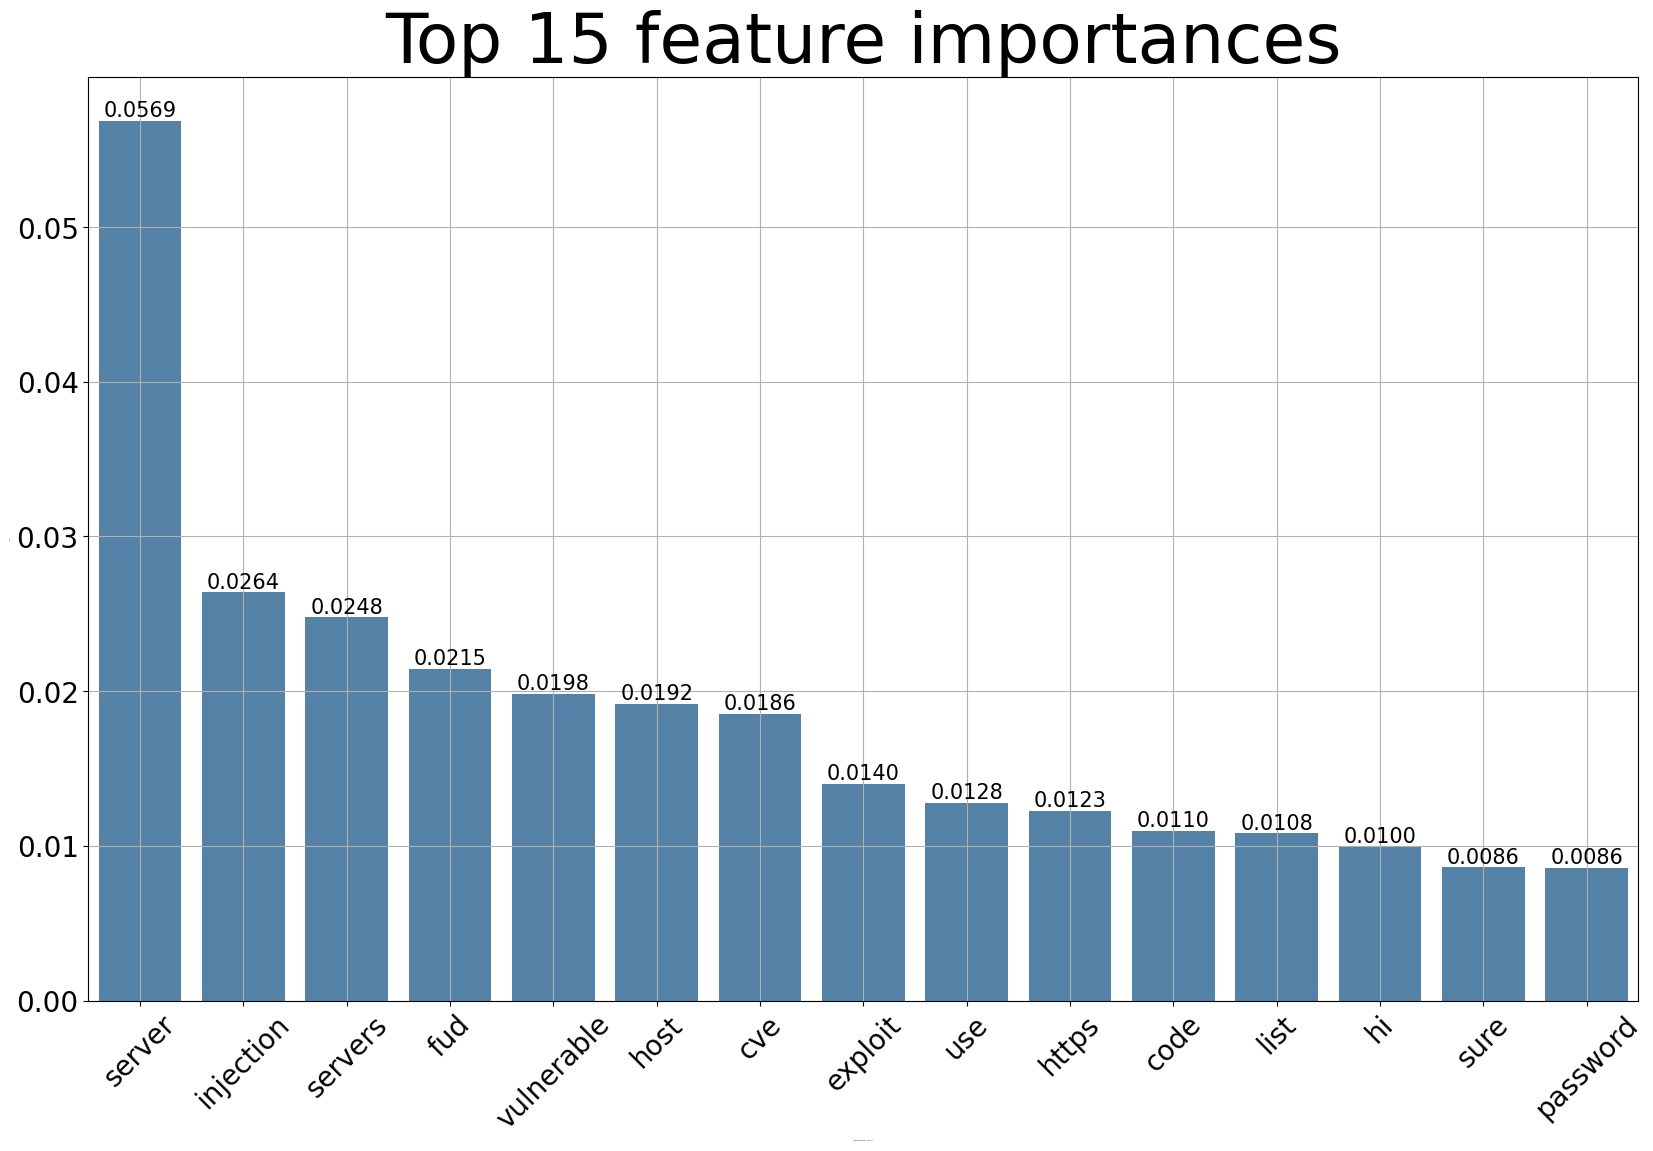

In [97]:
_, ax = plt.subplots(figsize=(20,12), nrows=1, ncols=1, sharex=False, sharey=False)

sns_fig = sns.barplot(
            data=forest_importances_df.iloc[:cfg.TOP_K_FEATURES],
            x=forest_importances_df.iloc[:cfg.TOP_K_FEATURES].columns[0],
            y=forest_importances_df.iloc[:cfg.TOP_K_FEATURES].columns[1],
            # orient="h",
            ax=ax,
            color="steelblue",
            #order=estado_df.sort_values(estado_df.columns[1], ascending=False)[estado_df.columns[0]]
           )

sns_fig.set_title(f"Top {cfg.TOP_K_FEATURES} feature importances", fontsize=50)
sns_fig.set_ylabel(f"Label", fontsize=0)
sns_fig.set_xlabel('Mean decrease in impurity', fontsize=0)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='x', rotation=45, labelsize=20)

# rotate the axis ticklabels
_ = sns_fig.tick_params(axis='y', labelsize=20)

# add annotation
_ = sns_fig.bar_label(sns_fig.containers[0], fmt='%.4f', fontsize=15,rotation=0)
ax.grid(True)
# add a space on y for the annotations
#sns_fig.margins(x=0.1)
# plt.savefig(f'{MODEL_PATH}RF_{label_to_focus}_{over_type}_feature_importance_{round(clf_rf_report["accuracy"], 3)}.png')

### SHAP

In [98]:
import shap
shap.initjs()

In [99]:
# np.bool = np.bool_

In [100]:
scaler   = clf_rf.best_estimator_.named_steps['scaler']
rf_model = clf_rf.best_estimator_.named_steps['classifier']

shap_explainer = shap.TreeExplainer(rf_model)

In [101]:
X_test_scaled         = scaler.transform(X_test)

In [108]:
TOP_SAMPLES = 10

#### Balanced

In [112]:
%%time
X_test_balanced_scaled = scaler.transform(X_test_balanced)
# shap_values_balanced = shap_explainer.shap_values(X_test_balanced)
shap_values_balanced = shap_explainer.shap_values(X_test_balanced_scaled[:TOP_SAMPLES], check_additivity=False)

CPU times: user 9.98 s, sys: 42 ms, total: 10 s
Wall time: 9.96 s


In [134]:
shap_values_balanced[0]

array([[ 9.62713799e+06, -9.91140693e-05, -1.72129835e+10],
       [ 5.43946923e+04, -4.20812919e-05,  2.44108011e+06],
       [ 1.67413152e+05, -3.32700194e-03,  2.94939166e+07],
       ...,
       [ 1.18485678e+05,  2.57915314e-05,  3.60136739e+06],
       [ 8.59349729e+04, -3.51145999e-04,  2.88588141e+06],
       [-7.08290060e+03, -2.21468323e-05, -1.04493820e+05]],
      shape=(366, 3))

In [130]:
shap_values_instance_narray =  np.mean(np.array(shap_values_balanced), axis=2)
shap_values_df = pd.DataFrame(shap_values_instance_narray, columns=feature_names).abs()
shap_values_melt_df = pd.melt(shap_values_df.T.reset_index(), id_vars="index", var_name="label", value_name="value")
shap_values_melt_df

,index,label,value
0,0day,0,5.734452e+09
1,able,0,8.318249e+05
2,access,0,9.887110e+06
3,according,0,9.662504e+03
4,account,0,2.772879e+09
...,...,...,...
3655,www,9,4.235358e+06
3656,xp,9,1.048646e+06
3657,xss,9,2.681906e+06
3658,yes,9,1.594016e+07


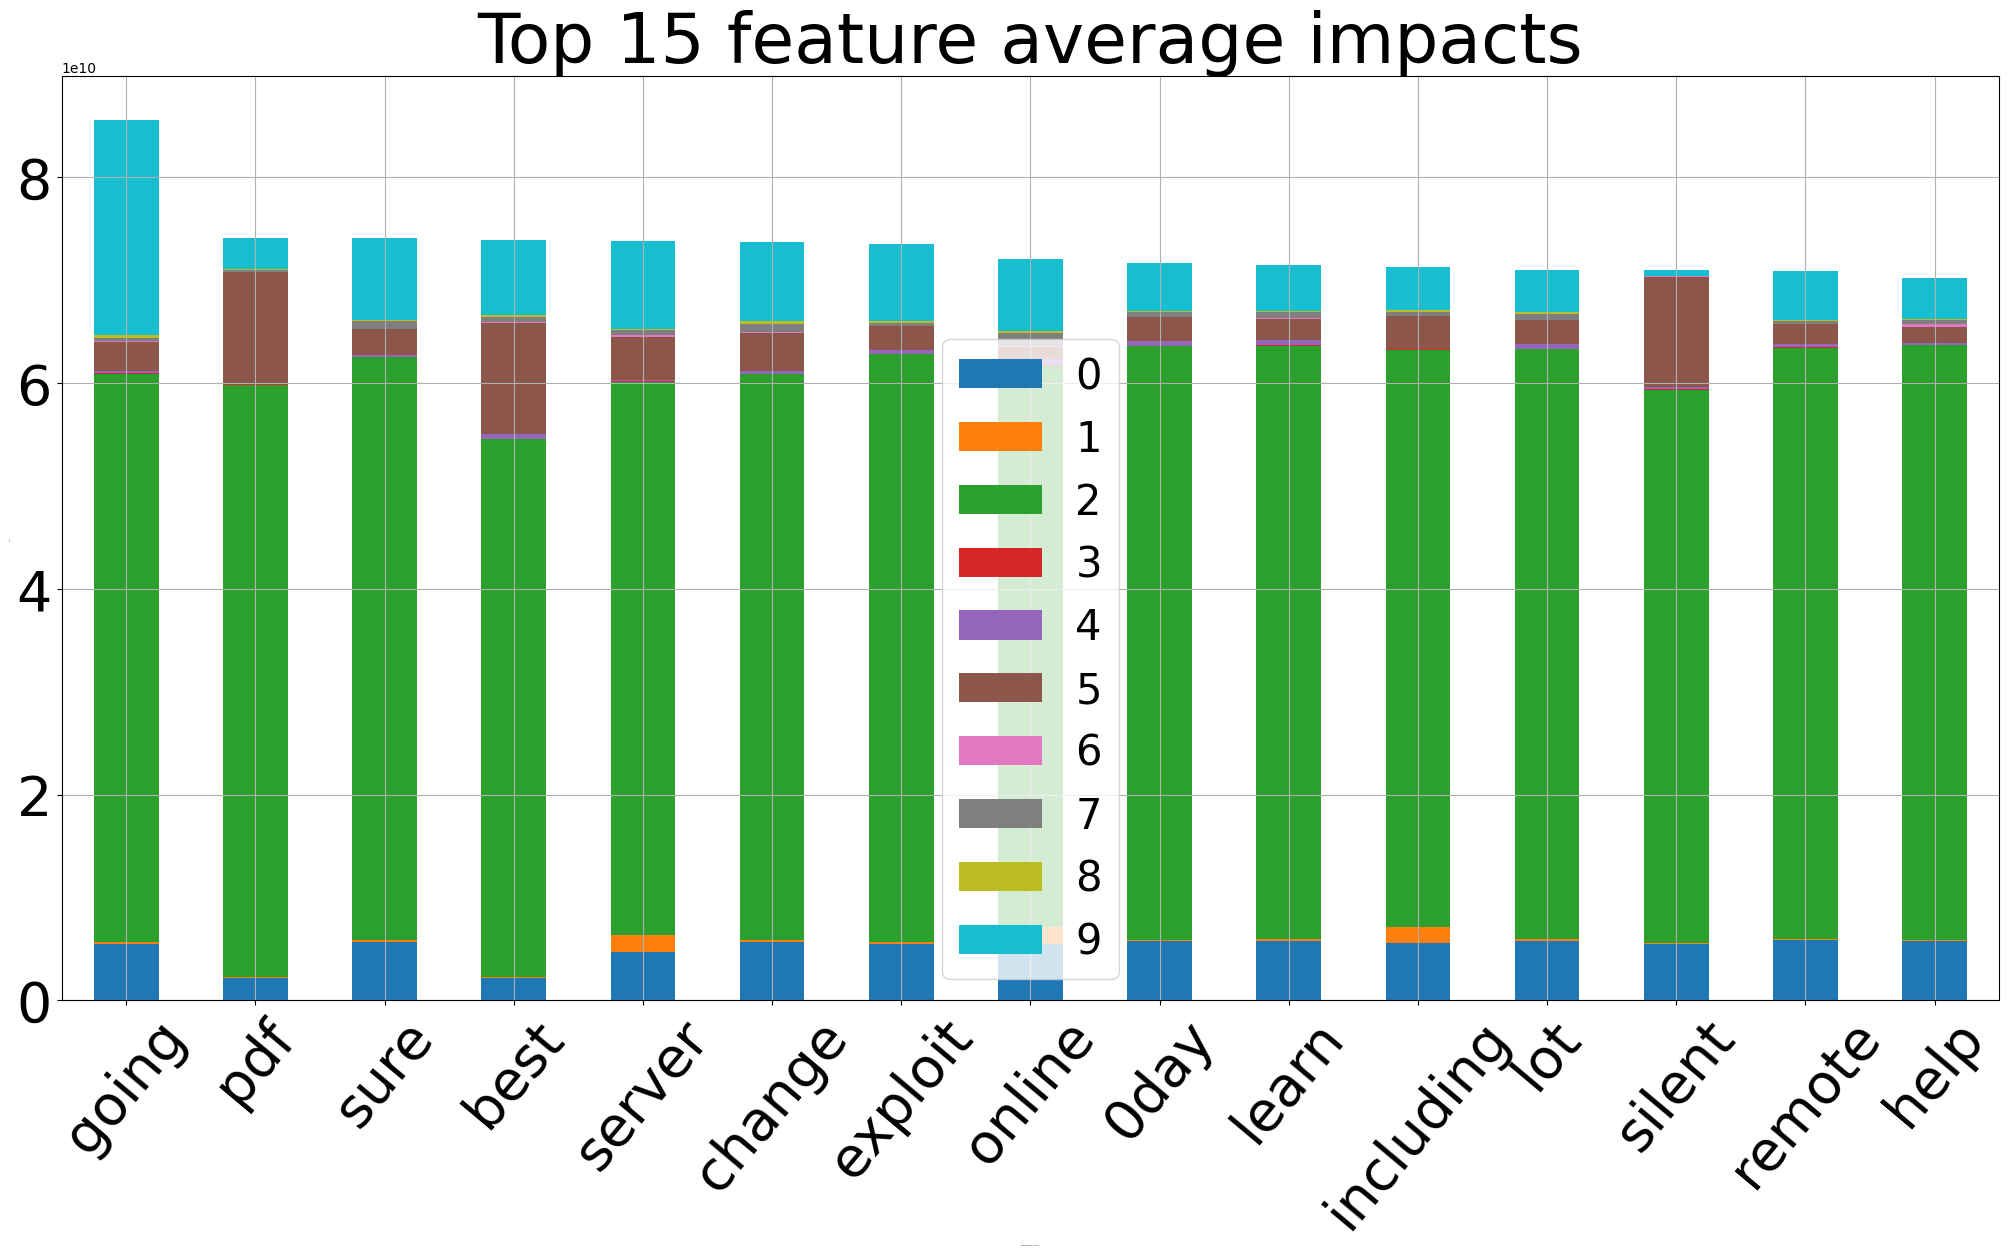

In [129]:
_, ax = plt.subplots(figsize=(25,12), nrows=1, ncols=1, sharex=False, sharey=False)

#shap_values_df.index = [ label_map[idx] for idx in list(shap_values_df.index) ]

mean_shap_values_df = shap_values_df.abs().sum().sort_values(ascending=False).reset_index()

top_k_features_names = mean_shap_values_df["index"][:15].values.tolist()
sort_df = shap_values_melt_df[ shap_values_melt_df["index"].isin(top_k_features_names) ]
sort_df['index'] = pd.Categorical(sort_df['index'], categories=top_k_features_names, ordered=True)
sort_df.sort_values(by=['index', 'label'], inplace=True)
# sort_df["label"] = sort_df["label"].apply(lambda x: label_map[x])
if label_to_focus=="crime_type":
    sort_df["label"] = sort_df["label"].apply(lambda x: x if x not in new_label.keys() else new_label[x])
pivot_df = sort_df.pivot_table(index='index', columns='label', values='value', aggfunc=np.sum, fill_value=0)

pivot_df.plot(kind='bar', stacked=True, ax=ax)
ax.set_title(f"Top {cfg.TOP_K_FEATURES} feature average impacts", fontsize=50)
ax.set_ylabel(f"Label", fontsize=0)
ax.set_xlabel('Mean decrease in impurity', fontsize=0)

# rotate the axis ticklabels
_ = ax.tick_params(axis='x', rotation=50, labelsize=40)

# rotate the axis ticklabels
_ = ax.tick_params(axis='y', labelsize=40)

# add annotation
# _ = ax.bar_label(sns_fig.containers[0], fmt='%.4f', fontsize=15,rotation=0)

# add legend
ax.legend(fontsize=30)
a,b = ax.get_ylim()
ax.set_ylim(a, b+0.0001)

ax.grid(True)
# plt.savefig(f'{MODEL_PATH}RF_SHAP_{label_to_focus}_{over_type}_mean_balanced_{round(clf_rf_report["accuracy"], 3)}.png')

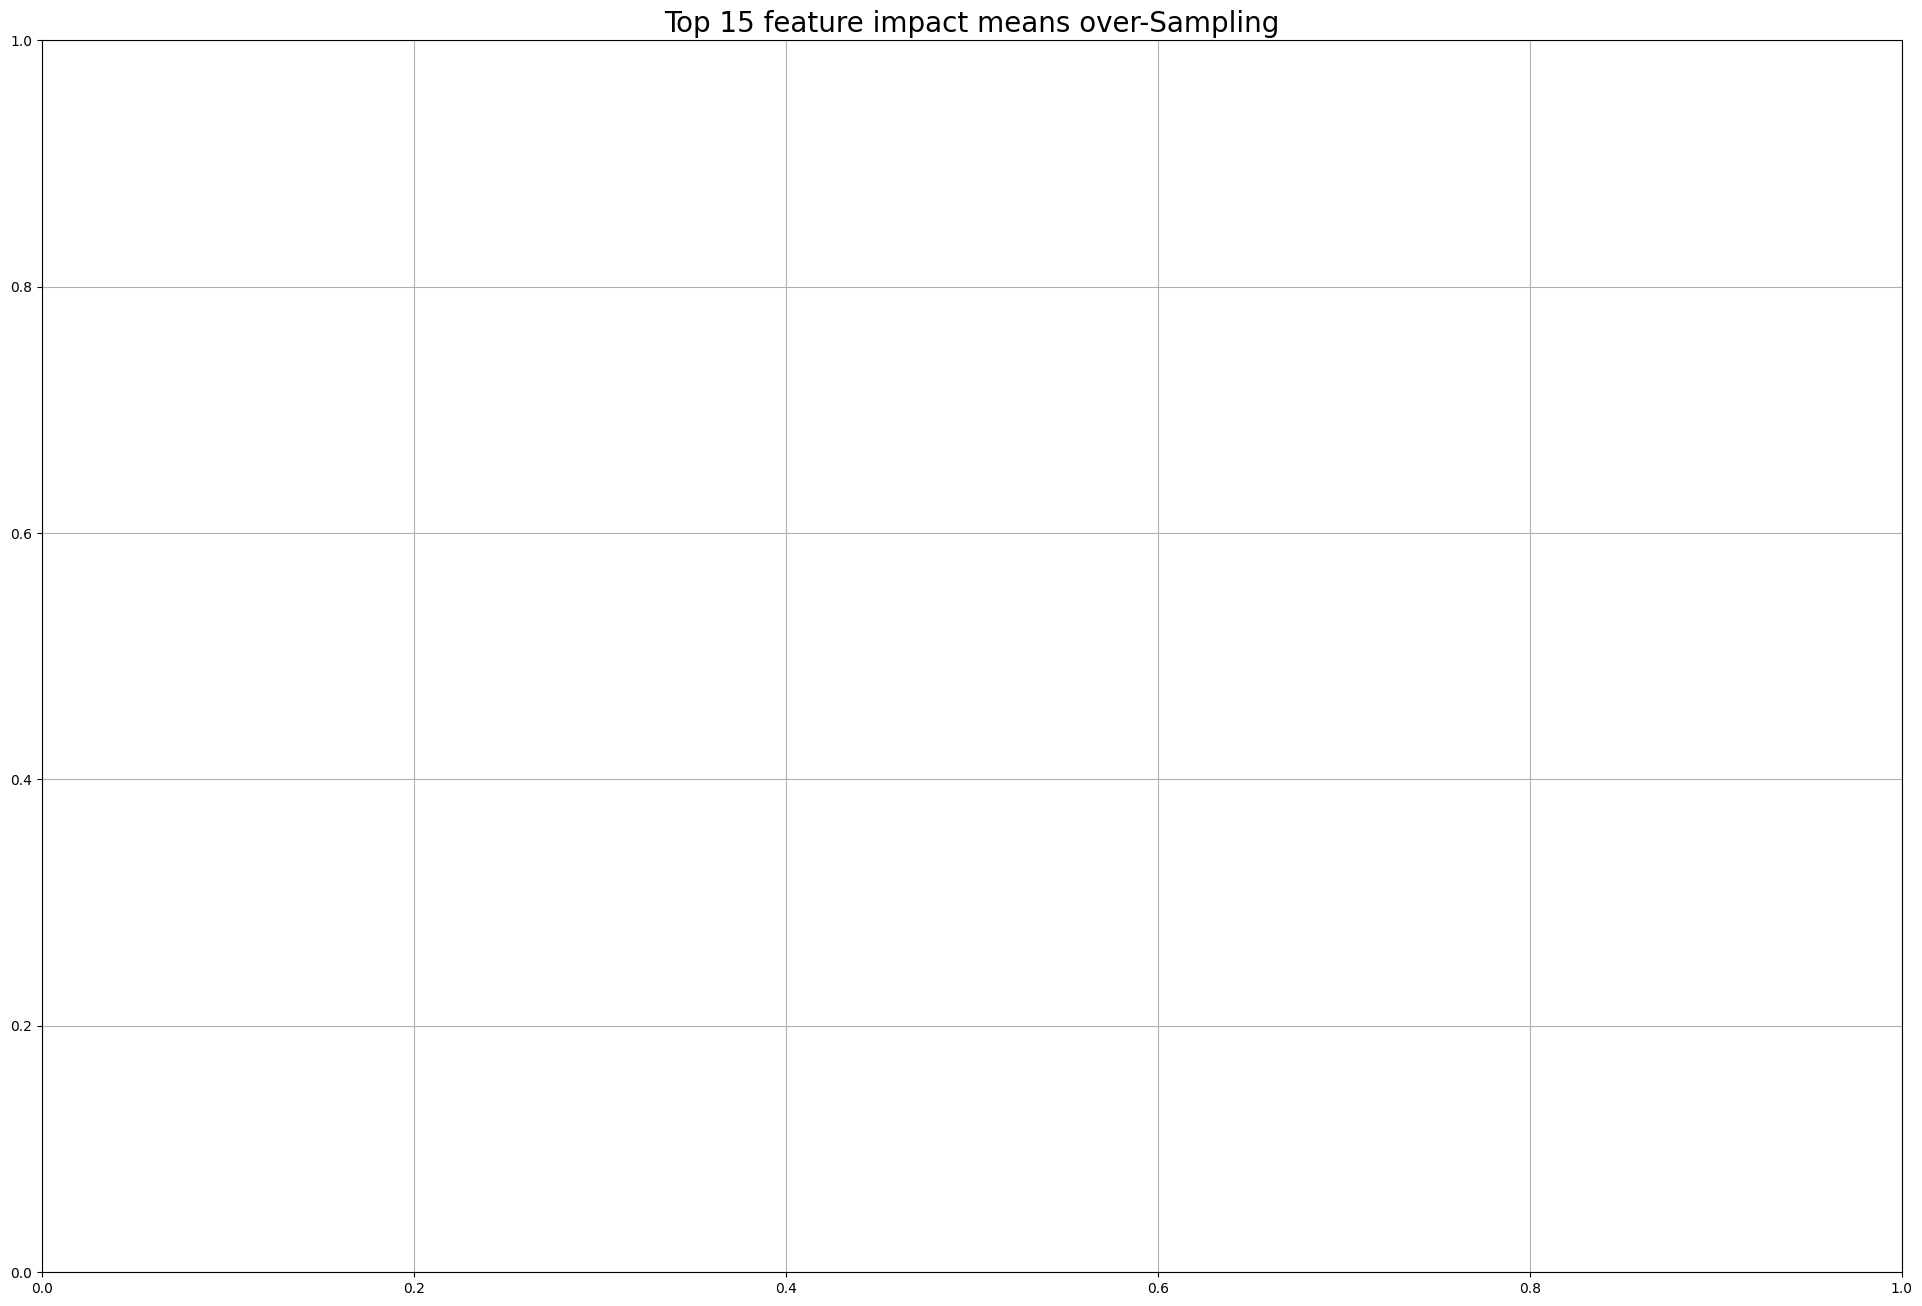

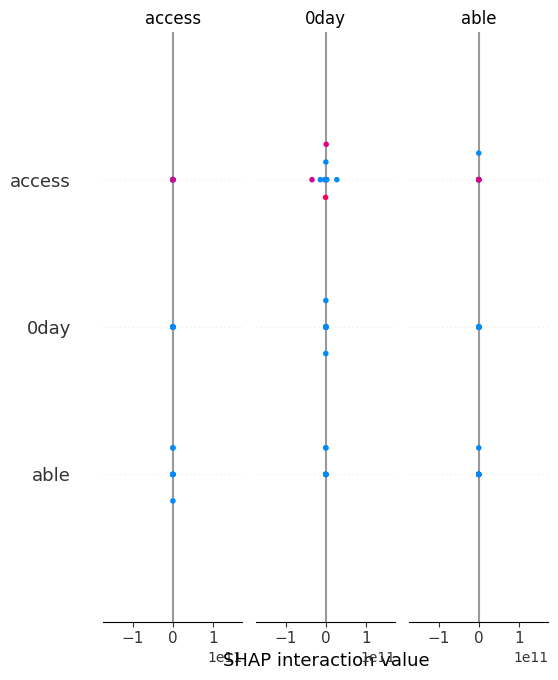

In [116]:
_, ax = plt.subplots(figsize=(24,16), nrows=1, ncols=1, sharex=False, sharey=False)
ax.set_title(f"Top {cfg.TOP_K_FEATURES} feature impact means {over_type}-Sampling", fontsize=20)
ax.grid(True)
shap.summary_plot(shap_values_balanced, X_test_balanced[:TOP_SAMPLES], feature_names=feature_names, show=False, class_names=labels)
# plt.savefig(f'{MODEL_PATH}RF_SHAP_{label_to_focus}_{over_type}_mean_balanced_{round(clf_rf_report["accuracy"], 3)}.png')